# 감시 카메라 이미지에서 위협 요소 탐지

군사 기지 감시 초소에서는 감시 카메라가 주기적으로 이미지를 촬영하고 있습니다. 해당 감시 카메라 시스템은 적의 침투나 이상 상황을 감지하기 위해 경고 표지판과 같은 빨간색 사각형 객체를 추적합니다. 이 문제의 목표는 주어진 감시 카메라 이미지에서 빨간색 경고 표지판(사각형 형태)을 탐지하여 그 좌표를 정확히 추출하는 프로그램을 작성하는 것입니다.

## 데이터 셋 설명

감시 카메라로 촬영된 이미지 파일(image_1.jpg, image_2.jpg, ..., image_100.jpg까지 100개의 이미지)은 data 폴더 바로 아래에 있습니다. 각 이미지에는 빨간색 사각형 객체(경고 표지판)가 1개 포함되어 있습니다.

## 문제 설명

 - 주어진 이미지에서 빨간색 사각형 경고 표지판의 좌표를 탐지하고 (left, right, top, bottom) 형식으로 출력하세요.
 - 이미지의 좌표 체계는 좌측 상단이 (0, 0)이며, x축은 오른쪽으로 증가하고, y축은 아래쪽으로 증가합니다. 모든 이미지의 가로 세로 픽셀 크기는 512x512이며, 우측 하단의 좌표는 (512, 512)입니다.
    - left, right은 x축이며 right의 값이 left보다 커야 합니다.
    - top, bottom은 y축이며 bottom의 값이 top의 값보다 커야 합니다.
 - OpenCV 라이브러리를 사용할 수 있습니다.

## 초기코드(Python)

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [7]:
import cv2

# 테스트 예시
for i in range(1, 101):
    filename = f"image_{i}.jpg"
    image_path = f"./drive/MyDrive/maicon24/day1/Problem#3/data/{filename}"

In [9]:
# 여기에 코드를 작성하세요.
import numpy as np
import pandas as pd

rows = []
for i in range(1, 101):
    filename = f"image_{i}.jpg"
    img = cv2.imread(f"./data/{filename}")          # BGR 순서로 읽힘 (Colab 경로 아님)

    b, g, r = cv2.split(img)

    # 1. BGR 마스크: R은 높고 G, B는 낮은 픽셀
    #    가이드: JPEG 압축 때문에 경계가 번지므로 R은 150~200 이상, G/B는 50~100 이하 정도에서 시작
    mask = ((r > 180) & (g < 75) & (b < 75)).astype(np.uint8) * 255

    # 2. (선택) 노이즈 제거: 작은 점 제거용 모폴로지
    #    가이드: 커널 3x3 정도, 노이즈가 없으면 생략 가능
    # kernel = np.ones((..., ...), np.uint8)
    # mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # 3. 윤곽선 검출
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 4. 가장 큰 덩어리를 선택 (노이즈 점이 섞여도 안전)
    c = max(contours, key=cv2.contourArea)

    # 5. 외접 사각형: boundingRect는 (x, y, w, h)를 반환
    x, y, w, h = cv2.boundingRect(c)
    left, right, top, bottom = x, x + w, y, y + h

    rows.append([filename, left, right, top, bottom])

df = pd.DataFrame(rows, columns=['filename', 'left', 'right', 'top', 'bottom'])
df.head()

,filename,left,right,top,bottom
0,image_1.jpg,302,334,329,428
1,image_2.jpg,236,283,103,172
2,image_3.jpg,312,338,181,229
3,image_4.jpg,15,42,380,444
4,image_5.jpg,111,192,473,505


### 최종 제출 파일

submission.csv라는 이름의 CSV 파일로 저장해주세요. 예를 들어 최종 제출 파일의 처음 5개(헤더 제외)의 레코드를 보면 다음과 같은 형태가 되어야 합니다.

| filename | left | right | top | bottom |
| --- | --- | --- | --- | --- |
| image_1.jpg | 217 | 277 | 85 | 152 |
| image_2.jpg | 98 | 175 | 398 | 494 |
| image_3.jpg | 92 | 182 | 418 | 498 |
| image_4.jpg | 175 | 253 | 454 | 487 |
| image_5.jpg | 268 | 363 | 235 | 273 |

In [ ]:
# 여기에 코드를 작성하세요.


### 결과 저장

채점을 위해, 위에서 구한 데이터를 현재 파일과 같은 디렉토리(.ipynb 파일이 있는 디렉토리)에 `submission.csv`이라는 이름으로 저장해주세요.

In [20]:
# 여기에 코드를 작성하세요.
print(list(sub.columns))

['Unnamed: 0', 'filename', 'left', 'right', 'top', 'bottom']


In [24]:
# csv 파일 저장 예시 - python
df.to_csv('submission.csv', index=False)

In [27]:
sub = pd.read_csv('submission.csv')

assert len(sub) == 100, '행 수가 100이 아님'
assert list(sub.columns) == ['filename', 'left', 'right', 'top', 'bottom']
assert (sub['right'] > sub['left']).all(), 'right <= left 인 행 있음'
assert (sub['bottom'] > sub['top']).all(), 'bottom <= top 인 행 있음'
assert sub[['left', 'right', 'top', 'bottom']].min().min() >= 0
assert sub[['left', 'right', 'top', 'bottom']].max().max() <= 512
print('형식 검사 통과')

형식 검사 통과


In [28]:
def iou(a, b):
    # a, b = (left, right, top, bottom)
    ix = max(0, min(a[1], b[1]) - max(a[0], b[0]))
    iy = max(0, min(a[3], b[3]) - max(a[2], b[2]))
    inter = ix * iy
    area = lambda t: (t[1] - t[0]) * (t[3] - t[2])
    return inter / (area(a) + area(b) - inter)

ref_rows = []
for fn in sub['filename']:
    img = cv2.imread(f'./data/{fn}')
    b, g, r = cv2.split(img)
    ys, xs = np.where((r > 180) & (g < 75) & (b < 75))      # 가이드: 앞 코드와 같은 임계값 또는 더 엄격하게
    ref_rows.append([fn, xs.min(), xs.max() + 1, ys.min(), ys.max() + 1])

ref = pd.DataFrame(ref_rows, columns=['filename', 'left', 'right', 'top', 'bottom'])

sub['iou'] = [iou(tuple(s), tuple(r_)) for s, r_ in
              zip(sub[['left', 'right', 'top', 'bottom']].values,
                  ref[['left', 'right', 'top', 'bottom']].values)]
print('평균 IoU:', sub['iou'].mean())
print(sub.sort_values('iou').head())         # 가장 어긋난 이미지 확인

평균 IoU: 1.0
      filename  left  right  top  bottom  iou
0  image_1.jpg   302    334  329     428  1.0
1  image_2.jpg   236    283  103     172  1.0
2  image_3.jpg   312    338  181     229  1.0
3  image_4.jpg    15     42  380     444  1.0
4  image_5.jpg   111    192  473     505  1.0


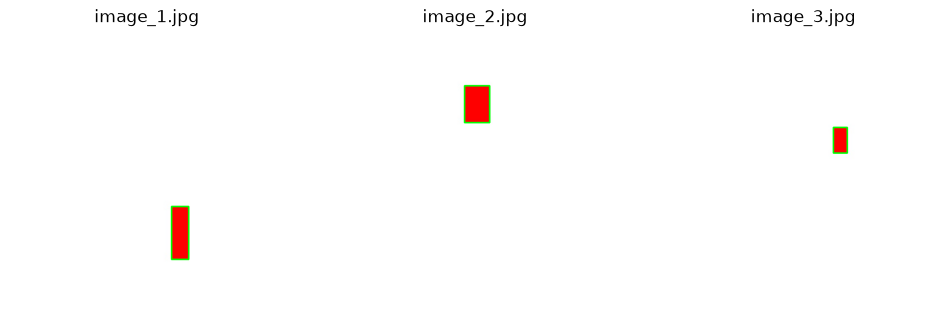

In [29]:
import matplotlib.pyplot as plt

def show(fn):
    img = cv2.cvtColor(cv2.imread(f'./data/{fn}'), cv2.COLOR_BGR2RGB)
    row = sub[sub['filename'] == fn].iloc[0]
    cv2.rectangle(img, (row['left'], row['top']), (row['right'], row['bottom']), (0, 255, 0), 2)
    plt.imshow(img); plt.title(fn); plt.axis('off')

# IoU가 낮은 이미지 몇 장과 무작위 몇 장을 확인
plt.figure(figsize=(12, 4))
for k, fn in enumerate(sub.sort_values('iou')['filename'].head(3)):
    plt.subplot(1, 3, k + 1); show(fn)
plt.show()